# Experiment: LLM Trust Labeling + Probabilistic Graph

This notebook implements:
1. LLM labeling via Ollama for trust metrics: `claim_trust_score`, `signal_trust_score`, `heuristic_pressure_score`, `competence_score`, `benevolence_score`, `integrity_score`, `predictability_score`.
2. Phase A validation on fake-news data with ground-truth labels.
3. Probabilistic graph modeling (naive Bayesian graph) and logistic baseline.
4. Phase B application on product listings (no truth labels) to produce trust-risk indices.


In [1]:
%pip install -q --upgrade pandas numpy scikit-learn tqdm datasets matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Run controls (edit this for each new run)
RUN_SAMPLE_SIZES = {
    'phase_a_target_rows': 240,
    'phase_b_target_rows': 300,
}
RUN_LIMITS = {
    # None means no per-phase call cap (labels all selected rows)
    'max_calls_per_phase': None,
}
RUN_ARCHIVE = {
    'enabled': True,
    'archive_folder_name': 'llm_trust_graph_archive',
}
print('Run sample sizes:', RUN_SAMPLE_SIZES)
print('Run limits:', RUN_LIMITS)
print('Archive settings:', RUN_ARCHIVE)


In [ ]:
# Archive existing artifacts (safety snapshot before new run)
from datetime import datetime
import shutil
from pathlib import Path
search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root_for_archive = None
for root in search_roots:
    if (root / 'experiment_trust').exists():
        project_root_for_archive = root.resolve()
        break
if project_root_for_archive is None:
    raise FileNotFoundError('Could not locate project root containing experiment_trust/.')
artifacts_dir_to_archive = project_root_for_archive / 'experiment_trust' / 'artifacts' / 'llm_trust_graph'
archive_enabled = bool(globals().get('RUN_ARCHIVE', {}).get('enabled', True))
archive_folder_name = str(globals().get('RUN_ARCHIVE', {}).get('archive_folder_name', 'llm_trust_graph_archive'))
archive_root_dir = project_root_for_archive / 'experiment_trust' / 'artifacts' / archive_folder_name
if not archive_enabled:
    print('Archiving disabled by RUN_ARCHIVE settings.')
elif not artifacts_dir_to_archive.exists() or not any(artifacts_dir_to_archive.iterdir()):
    print('No existing artifacts found to archive at:', artifacts_dir_to_archive)
else:
    run_info_path = artifacts_dir_to_archive / 'run_info.json'
    if run_info_path.exists():
        ts = run_info_path.stat().st_mtime
    else:
        ts = max(p.stat().st_mtime for p in artifacts_dir_to_archive.rglob('*') if p.is_file())
    stamp = datetime.fromtimestamp(ts).strftime('%Y%m%d_%H%M%S')
    archive_root_dir.mkdir(parents=True, exist_ok=True)
    archive_target = archive_root_dir / f'run_{stamp}'
    suffix = 1
    while archive_target.exists():
        archive_target = archive_root_dir / f'run_{stamp}_{suffix}'
        suffix += 1
    shutil.copytree(artifacts_dir_to_archive, archive_target)
    archived_files = sum(1 for p in archive_target.rglob('*') if p.is_file())
    print('Archived previous artifacts to:', archive_target)
    print('Archived file count:', archived_files)


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = None
for root in search_roots:
    if (root / 'experiment_trust').exists() and (root / 'trust_agent').exists():
        project_root = root.resolve()
        break

if project_root is None:
    raise FileNotFoundError('Could not locate project root containing experiment_trust/ and trust_agent/.')

import sys
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiment_trust.llm_trust_graph_pipeline import (
    LabelingConfig,
    PhaseConfig,
    apply_phase_b_inference,
    build_label_prompt,
    label_dataframe_with_ollama,
    load_fake_news_dataset,
    load_product_dataset,
    run_duplicate_label_check,
    run_ollama_label,
    run_phase_a_training,
    save_json,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 140)
project_root


PosixPath('/Users/lohzh/Desktop/cs3263-repo')

In [ ]:
# Configuration
OLLAMA_MODEL = 'llama3.1:8b'
FAKE_NEWS_LOCAL_PATH = None  # Optional local CSV/JSON path
PRODUCT_DATASET_PATH = project_root / 'data/raw/amazon-product-data/dataset/train.csv'
sample_sizes = globals().get('RUN_SAMPLE_SIZES', {})
run_limits = globals().get('RUN_LIMITS', {})
PHASE_A_TARGET_ROWS = int(sample_sizes.get('phase_a_target_rows', 120))
PHASE_B_TARGET_ROWS = int(sample_sizes.get('phase_b_target_rows', 150))
MAX_CALLS_PER_PHASE = run_limits.get('max_calls_per_phase', 120)  # None -> label all selected rows
RANDOM_STATE = 42
TEST_SIZE = 0.25
DUPLICATE_FRACTION = 0.1
MAX_OUTPUT_TOKENS = 220
CONTEXT_TOKENS = 1024
artifacts_dir = project_root / 'experiment_trust' / 'artifacts' / 'llm_trust_graph'
artifacts_dir.mkdir(parents=True, exist_ok=True)
phase_a_cache = artifacts_dir / 'phase_a_labels.jsonl'
phase_b_cache = artifacts_dir / 'phase_b_labels.jsonl'
label_config = LabelingConfig(
    model=OLLAMA_MODEL,
    timeout_seconds=180,
    keepalive='10m',
    max_text_chars=1200,
    max_output_tokens=MAX_OUTPUT_TOKENS,
    context_tokens=CONTEXT_TOKENS,
    duplicate_fraction=DUPLICATE_FRACTION,
    random_state=RANDOM_STATE,
)
phase_config = PhaseConfig(
    target_rows=PHASE_A_TARGET_ROWS,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
print('Artifacts dir:', artifacts_dir)
print('PHASE_A_TARGET_ROWS =', PHASE_A_TARGET_ROWS)
print('PHASE_B_TARGET_ROWS =', PHASE_B_TARGET_ROWS)
print('MAX_CALLS_PER_PHASE =', MAX_CALLS_PER_PHASE)


In [4]:
# Phase A: fake-news dataset load
phase_a_df = load_fake_news_dataset(
    local_path=FAKE_NEWS_LOCAL_PATH,
    target_rows=PHASE_A_TARGET_ROWS,
    random_state=RANDOM_STATE,
)

print('Phase A rows:', len(phase_a_df))
print('Phase A class distribution:')
display(phase_a_df['label_truth'].value_counts(dropna=False))
display(phase_a_df.head(5))


/Users/lohzh/Desktop/cs3263-repo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phase A rows: 6
Phase A class distribution:


label_truth
0    3
1    3
Name: count, dtype: int64

,record_id,text,label_truth
0,syn_1,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!,0
1,syn_2,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes.",1
2,syn_3,"Miracle herb reverses diabetes in 24 hours, doctors don't want you to know.",0
3,syn_4,National weather service reports above-average rainfall this quarter with updated regional forecasts.,1
4,syn_5,Act now! This shocking report proves all bank deposits vanish next week.,0


In [5]:
# Phase A: one-sample Ollama smoke test (before batch labeling)
sample_row = phase_a_df.iloc[0]
sample_text = str(sample_row['text'])[:label_config.max_text_chars]
sample_prompt = build_label_prompt(domain='fake_news', text=sample_text)
try:
    sample_label = run_ollama_label(
        prompt=sample_prompt,
        model=label_config.model,
        timeout_seconds=label_config.timeout_seconds,
        keepalive=label_config.keepalive,
        max_output_tokens=label_config.max_output_tokens,
        context_tokens=label_config.context_tokens,
    )
    print('One-sample label OK. Returned keys:', sorted(sample_label.keys()))
    display(pd.DataFrame([sample_label]))
except Exception as exc:
    print('One-sample label failed:', exc)
    raise


One-sample label OK. Returned keys: ['benevolence_bucket', 'benevolence_score', 'claim_trust_bucket', 'claim_trust_score', 'competence_bucket', 'competence_score', 'heuristic_pressure_bucket', 'heuristic_pressure_score', 'integrity_bucket', 'integrity_score', 'overall_confidence', 'predictability_bucket', 'predictability_score', 'rationale_claim', 'rationale_pressure', 'rationale_signal', 'signal_trust_bucket', 'signal_trust_score']


,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,claim_trust_bucket,signal_trust_bucket,heuristic_pressure_bucket,rationale_claim,rationale_signal,rationale_pressure,overall_confidence,competence_bucket,benevolence_bucket,integrity_bucket,predictability_bucket
0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,low,low,high,The claim is implausible and contradicts established scientific knowledge.,The language used is sensationalized and lacks professional tone.,The use of 'Breaking' and 'Government hides this truth!' creates a sense of urgency and manipulation.,0.8,low,low,low,medium


In [6]:
# Phase A: LLM labeling
phase_a_labeled = label_dataframe_with_ollama(
    phase_a_df,
    id_col='record_id',
    text_col='text',
    domain='fake_news',
    cache_path=phase_a_cache,
    config=label_config,
    max_rows=PHASE_A_TARGET_ROWS,
    max_calls=MAX_CALLS_PER_PHASE,
)
phase_a_display_cols = [
    'record_id', 'label_truth',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'overall_confidence'
]
print('Phase A labeled rows:', len(phase_a_labeled))
if len(phase_a_labeled) == 0:
    print(f'No successful labels returned. Inspect recent errors in: {phase_a_cache}')
    if phase_a_cache.exists():
        error_rows = []
        with phase_a_cache.open('r', encoding='utf-8') as handle:
            for line in handle:
                try:
                    rec = json.loads(line)
                except Exception:
                    continue
                if 'error' in rec:
                    error_rows.append({'record_id': rec.get('record_id'), 'error': rec.get('error')})
        if error_rows:
            display(pd.DataFrame(error_rows).tail(5))
else:
    missing_cols = [c for c in phase_a_display_cols if c not in phase_a_labeled.columns]
    if missing_cols:
        print('Missing columns in labeled output:', missing_cols)
    available_cols = [c for c in phase_a_display_cols if c in phase_a_labeled.columns]
    display(phase_a_labeled[available_cols].head(10))


Labeling fake_news: 100%|██████████| 6/6 [00:30<00:00,  5.07s/it]

Phase A labeled rows: 6


,record_id,label_truth,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,overall_confidence
0,syn_1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.80
1,syn_2,1,0.9,1.0,0.0,0.8,0.7,0.9,0.6,0.85
2,syn_3,0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.80
3,syn_4,1,0.9,0.8,0.1,0.7,0.6,0.9,0.8,0.85
4,syn_5,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.90
5,syn_6,1,0.9,0.8,0.1,0.7,0.6,0.9,0.8,0.85


In [7]:
# Optional duplicate consistency check
phase_a_dup = run_duplicate_label_check(
    phase_a_labeled,
    id_col='record_id',
    text_col='text',
    domain='fake_news',
    cache_path=phase_a_cache,
    config=label_config,
)

if len(phase_a_dup):
    print('Duplicate rows:', len(phase_a_dup))
    print('Mean absolute difference (all metrics):', round(float(phase_a_dup['dup_abs_diff_mean'].mean()), 4))
    display(phase_a_dup[[
        'record_id',
        'dup_abs_diff_claim', 'dup_abs_diff_signal', 'dup_abs_diff_pressure',
        'dup_abs_diff_competence', 'dup_abs_diff_benevolence',
        'dup_abs_diff_integrity', 'dup_abs_diff_predictability',
        'dup_abs_diff_mean'
    ]].head(10))
else:
    print('Duplicate check skipped or no duplicate rows available.')


Duplicate rows: 1
Mean absolute difference (all metrics): 0.0714


,record_id,dup_abs_diff_claim,dup_abs_diff_signal,dup_abs_diff_pressure,dup_abs_diff_competence,dup_abs_diff_benevolence,dup_abs_diff_integrity,dup_abs_diff_predictability,dup_abs_diff_mean
0,syn_1,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.071429


In [8]:
# Phase A model training and evaluation
phase_a_result = run_phase_a_training(phase_a_labeled, phase_config=phase_config)

metrics_df = phase_a_result['metrics']
print('Phase A metrics:')
display(metrics_df)

graph_model = phase_a_result['graph_model']
logistic_model = phase_a_result['logistic_model']


Phase A metrics:


,model,auc,brier,log_loss
0,naive_bayes_graph,1.0,0.000075,0.00682
1,logistic_baseline,1.0,0.056503,0.27130


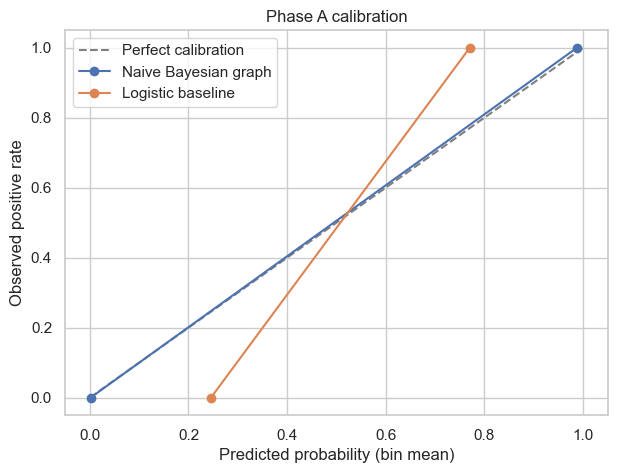

In [9]:
# Calibration curves on Phase A test split
cal_graph = phase_a_result['calibration_graph']
cal_log = phase_a_result['calibration_logistic']

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(cal_graph['pred_bin_mean'], cal_graph['true_rate'], marker='o', label='Naive Bayesian graph')
plt.plot(cal_log['pred_bin_mean'], cal_log['true_rate'], marker='o', label='Logistic baseline')
plt.xlabel('Predicted probability (bin mean)')
plt.ylabel('Observed positive rate')
plt.title('Phase A calibration')
plt.legend()
plt.show()


In [10]:
# Phase B: product dataset load
phase_b_df = load_product_dataset(
    product_csv_path=PRODUCT_DATASET_PATH,
    target_rows=PHASE_B_TARGET_ROWS,
    random_state=RANDOM_STATE,
)

print('Phase B rows:', len(phase_b_df))
display(phase_b_df[['record_id', 'PRODUCT_ID', 'PRODUCT_TYPE_ID', 'TITLE']].head(5))


Phase B rows: 150


,record_id,PRODUCT_ID,PRODUCT_TYPE_ID,TITLE
0,659984,659984,1,Calendrier sacre maya 2005-2006
1,433902,433902,114,Fractured Reality
2,1499195,1499195,8501,The Golden Butterfly the most daring illusion of the age - performend by Harry (Heinrich) Keller (1849-1922) He was a predecessor to Hou...
3,2641984,2641984,12228,"10x30 Contemporary Bronze Complete Wood Panoramic Frame with UV Acrylic, Foam Board Backing, & Hardware"
4,154989,154989,6320,"Quality By Experimental Design, 3rd Edition (Quality and Reliability)"


In [11]:
# Phase B: LLM labeling
phase_b_labeled = label_dataframe_with_ollama(
    phase_b_df,
    id_col='record_id',
    text_col='text',
    domain='product',
    cache_path=phase_b_cache,
    config=label_config,
    max_rows=PHASE_B_TARGET_ROWS,
    max_calls=MAX_CALLS_PER_PHASE,
)
phase_b_display_cols = [
    'record_id',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'overall_confidence'
]
print('Phase B labeled rows:', len(phase_b_labeled))
if len(phase_b_labeled) == 0:
    print(f'No successful labels returned. Inspect recent errors in: {phase_b_cache}')
else:
    missing_cols = [c for c in phase_b_display_cols if c not in phase_b_labeled.columns]
    if missing_cols:
        print('Missing columns in labeled output:', missing_cols)
    available_cols = [c for c in phase_b_display_cols if c in phase_b_labeled.columns]
    display(phase_b_labeled[available_cols].head(10))


Labeling product:  85%|████████▍ | 127/150 [34:26<06:14, 16.27s/it] 

Phase B labeled rows: 120


,record_id,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,overall_confidence
0,659984,0.25,0.75,0.25,0.5,0.5,0.75,0.5,0.80
1,433902,0.50,0.50,0.50,0.5,0.5,0.50,0.5,0.80
2,1499195,0.60,0.40,0.20,0.7,0.8,0.90,0.5,0.80
3,2641984,0.60,0.80,0.20,0.9,0.7,0.50,0.4,0.80
4,154989,1.00,1.00,0.00,1.0,1.0,1.00,1.0,0.90
5,346570,0.50,1.00,0.00,0.5,0.5,0.50,0.5,0.80
6,2067198,0.80,0.90,0.10,0.7,0.6,0.50,0.8,0.85
7,373253,0.50,0.50,0.50,0.5,0.5,0.50,0.5,0.80
8,2536585,0.20,0.80,0.40,0.6,0.4,0.30,0.5,0.85
9,1578439,0.60,0.80,0.20,0.7,0.9,0.50,0.4,0.80


In [12]:
# Phase B inference (no truth labels): trust-risk indices
phase_b_scored = apply_phase_b_inference(
    phase_b_labeled,
    graph_model=graph_model,
    logistic_model=logistic_model,
)

display(
    phase_b_scored[[
        'record_id', 'PRODUCT_ID', 'PRODUCT_TYPE_ID',
        'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
        'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
        'trust_risk_index_graph', 'graph_uncertainty_entropy'
    ]]
    .sort_values('trust_risk_index_graph', ascending=False)
    .head(15)
)


,record_id,PRODUCT_ID,PRODUCT_TYPE_ID,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,trust_risk_index_graph,graph_uncertainty_entropy
54,1094496,1094496,804,0.5,0.2,0.8,0.4,0.6,0.3,0.5,0.964286,0.222285
53,260809,260809,0,0.5,0.2,0.8,0.4,0.6,0.3,0.5,0.964286,0.222285
77,171776,171776,166,0.2,0.4,0.6,0.3,0.1,0.5,0.2,0.964286,0.222285
8,2536585,2536585,2968,0.2,0.8,0.4,0.6,0.4,0.3,0.5,0.750000,0.811278
7,373253,373253,12743,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.500000,1.000000
76,714413,714413,225,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.500000,1.000000
1,433902,433902,114,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.500000,1.000000
65,219495,219495,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.500000,1.000000
85,567741,567741,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.500000,1.000000
46,2307331,2307331,6540,0.2,0.8,0.4,0.6,0.9,0.7,0.5,0.500000,1.000000


In [13]:
# Save outputs
phase_a_labeled_path = artifacts_dir / 'phase_a_labeled.csv'
phase_a_metrics_path = artifacts_dir / 'phase_a_metrics.csv'
phase_a_cal_graph_path = artifacts_dir / 'phase_a_calibration_graph.csv'
phase_a_cal_log_path = artifacts_dir / 'phase_a_calibration_logistic.csv'
phase_b_scored_path = artifacts_dir / 'phase_b_scored.csv'
phase_a_dup_path = artifacts_dir / 'phase_a_duplicate_check.csv'
phase_a_labeled.to_csv(phase_a_labeled_path, index=False)
metrics_df.to_csv(phase_a_metrics_path, index=False)
phase_a_result['calibration_graph'].to_csv(phase_a_cal_graph_path, index=False)
phase_a_result['calibration_logistic'].to_csv(phase_a_cal_log_path, index=False)
phase_b_scored.to_csv(phase_b_scored_path, index=False)
if len(phase_a_dup):
    phase_a_dup.to_csv(phase_a_dup_path, index=False)
graph_model_json = {
    'class_probs': {str(k): float(v) for k, v in graph_model['class_probs'].items()},
    'cpds': {
        col: {str(cls): probs for cls, probs in class_map.items()}
        for col, class_map in graph_model['cpds'].items()
    },
    'bucket_columns': graph_model.get('bucket_columns', []),
}
save_json(artifacts_dir / 'graph_model.json', graph_model_json)
run_info = {
    'ollama_model': OLLAMA_MODEL,
    'fake_news_local_path': str(FAKE_NEWS_LOCAL_PATH) if FAKE_NEWS_LOCAL_PATH else None,
    'product_dataset_path': str(PRODUCT_DATASET_PATH),
    'phase_a_rows_loaded': int(len(phase_a_df)),
    'phase_a_rows_labeled': int(len(phase_a_labeled)),
    'phase_b_rows_loaded': int(len(phase_b_df)),
    'phase_b_rows_labeled': int(len(phase_b_labeled)),
    'max_calls_per_phase': MAX_CALLS_PER_PHASE,
    'metrics': metrics_df.to_dict(orient='records'),
    'artifacts': {
        'phase_a_labeled': str(phase_a_labeled_path),
        'phase_a_metrics': str(phase_a_metrics_path),
        'phase_a_calibration_graph': str(phase_a_cal_graph_path),
        'phase_a_calibration_logistic': str(phase_a_cal_log_path),
        'phase_b_scored': str(phase_b_scored_path),
        'phase_a_cache_jsonl': str(phase_a_cache),
        'phase_b_cache_jsonl': str(phase_b_cache),
        'graph_model': str(artifacts_dir / 'graph_model.json'),
    },
}
save_json(artifacts_dir / 'run_info.json', run_info)
print('Saved run artifacts to:', artifacts_dir)
display(pd.DataFrame(run_info['metrics']))


Saved run artifacts to: /Users/lohzh/Desktop/cs3263-repo/experiment_trust/artifacts/llm_trust_graph


,model,auc,brier,log_loss
0,naive_bayes_graph,1.0,0.000075,0.00682
1,logistic_baseline,1.0,0.056503,0.27130


## Notes
- Re-running the notebook reuses cached labels in `phase_a_labels.jsonl` and `phase_b_labels.jsonl`.
- Increase `PHASE_A_TARGET_ROWS`, `PHASE_B_TARGET_ROWS`, and `MAX_CALLS_PER_PHASE` for larger runs.
- For strict validation, set `FAKE_NEWS_LOCAL_PATH` to a known dataset and keep synthetic fallback only for smoke tests.


## Stage Visualizations

The cells below visualize each stage of the pipeline from raw LLM labels to BN-adjusted outcomes.


### Visualization 1: Fake-News LLM Label Distributions

This plot shows how raw LLM trust labels differ between true and fake news items. If the labeling is useful, true items should generally have higher claim/signal/CBIP scores and fake items should have higher heuristic pressure.


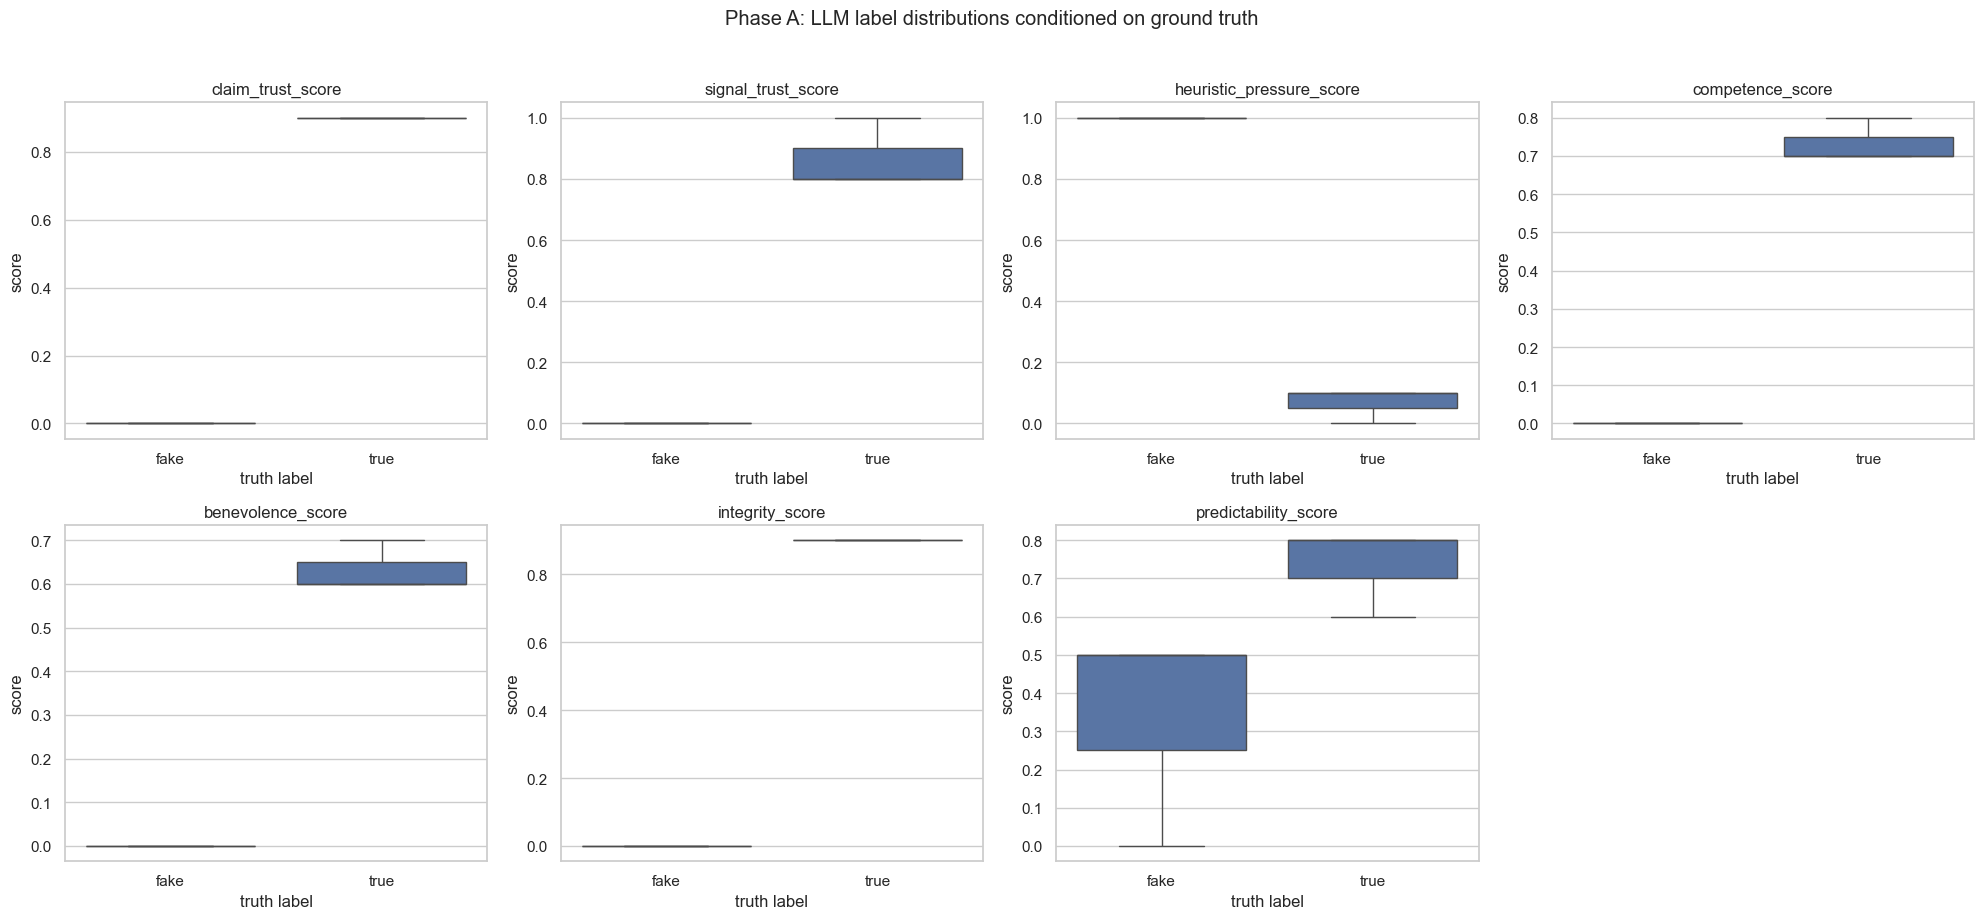

In [14]:
# 1) Phase A (Fake News): Raw LLM label distributions vs truth
phase_a_metrics = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
phase_a_plot_df = phase_a_labeled.copy()
phase_a_plot_df['label_truth_name'] = phase_a_plot_df['label_truth'].map({0: 'fake', 1: 'true'})
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, metric in zip(axes.flatten(), phase_a_metrics):
    sns.boxplot(data=phase_a_plot_df, x='label_truth_name', y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('truth label')
    ax.set_ylabel('score')
# Hide the 8th empty panel
axes.flatten()[-1].axis('off')
plt.suptitle('Phase A: LLM label distributions conditioned on ground truth', y=1.02)
plt.tight_layout()
plt.show()


### Visualization 2: Fake-News BN-Adjusted Outcomes

This view compares model-adjusted outputs on the held-out fake-news test set. You can see class separation for BN and logistic posteriors, and whether both models agree on the same examples (scatter near diagonal).


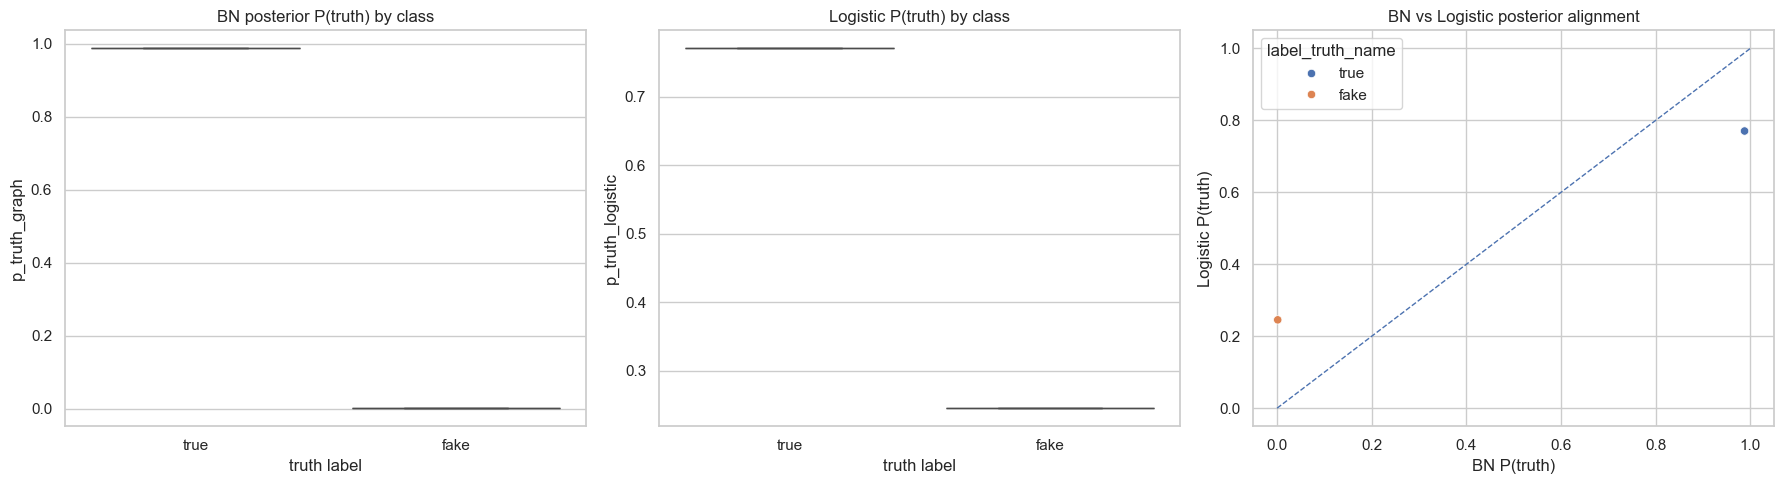

,model,auc,brier,log_loss
0,naive_bayes_graph,1.0,0.000075,0.00682
1,logistic_baseline,1.0,0.056503,0.27130


In [15]:
# 2) Phase A (Fake News): BN/logistic adjusted outcomes on held-out test split
phase_a_test_vis = phase_a_result['test_df'].copy()
phase_a_test_vis['p_truth_graph'] = phase_a_result['test_pred_graph']
phase_a_test_vis['p_truth_logistic'] = phase_a_result['test_pred_logistic']
phase_a_test_vis['risk_graph'] = 1.0 - phase_a_test_vis['p_truth_graph']
phase_a_test_vis['risk_logistic'] = 1.0 - phase_a_test_vis['p_truth_logistic']
phase_a_test_vis['label_truth_name'] = phase_a_test_vis['label_truth'].map({0: 'fake', 1: 'true'})
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=phase_a_test_vis, x='label_truth_name', y='p_truth_graph', ax=axes[0])
axes[0].set_title('BN posterior P(truth) by class')
axes[0].set_xlabel('truth label')
sns.boxplot(data=phase_a_test_vis, x='label_truth_name', y='p_truth_logistic', ax=axes[1])
axes[1].set_title('Logistic P(truth) by class')
axes[1].set_xlabel('truth label')
sns.scatterplot(
    data=phase_a_test_vis,
    x='p_truth_graph',
    y='p_truth_logistic',
    hue='label_truth_name',
    ax=axes[2],
)
axes[2].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[2].set_title('BN vs Logistic posterior alignment')
axes[2].set_xlabel('BN P(truth)')
axes[2].set_ylabel('Logistic P(truth)')
plt.tight_layout()
plt.show()
display(phase_a_result['metrics'])


### Visualization 3: Product Raw LLM Label Distributions

This plot summarizes how the LLM labels the product dataset before any BN adjustment. It gives the baseline label shape (e.g., where scores cluster and whether pressure is high/low overall).


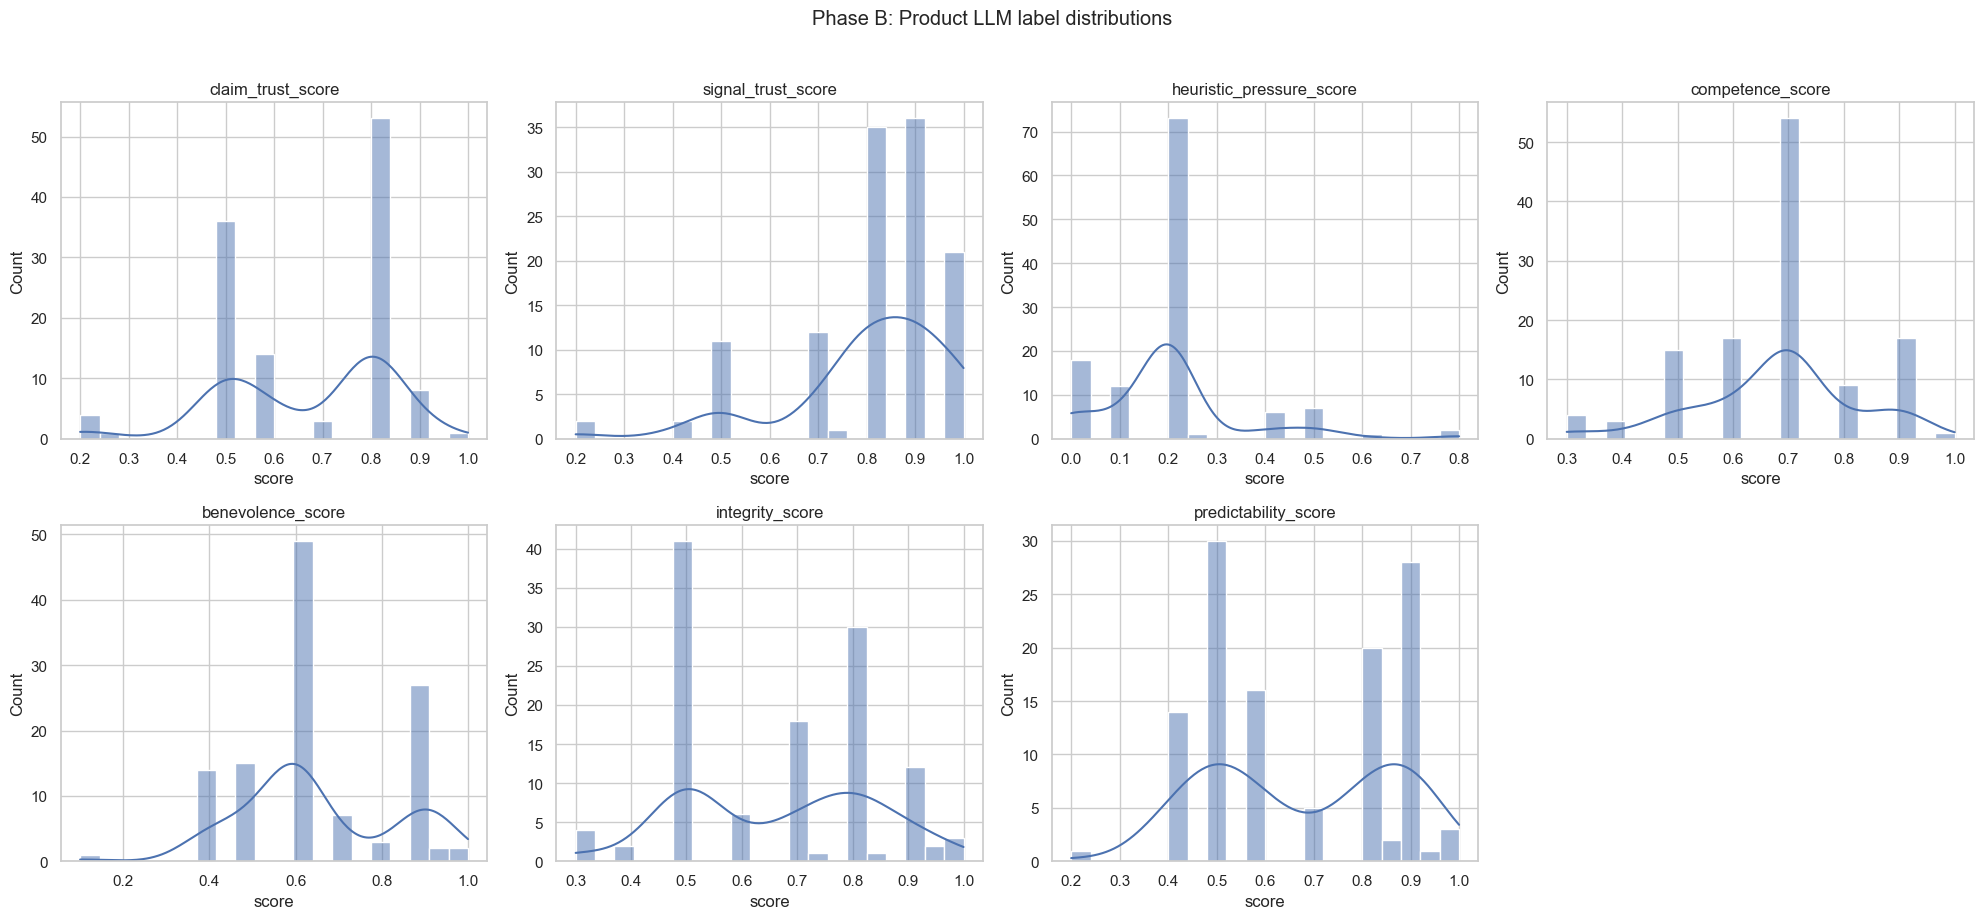

In [16]:
# 3) Phase B (Products): Raw LLM label distributions
phase_b_metrics = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, metric in zip(axes.flatten(), phase_b_metrics):
    sns.histplot(phase_b_labeled[metric], bins=20, kde=True, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('score')
axes.flatten()[-1].axis('off')
plt.suptitle('Phase B: Product LLM label distributions', y=1.02)
plt.tight_layout()
plt.show()


### Visualization 4: Product BN-Adjusted Outcomes

This view shows BN-adjusted truth likelihood, derived trust-risk index, and uncertainty entropy for products. Use it to understand how calibration changes raw labels and where predictions remain uncertain.


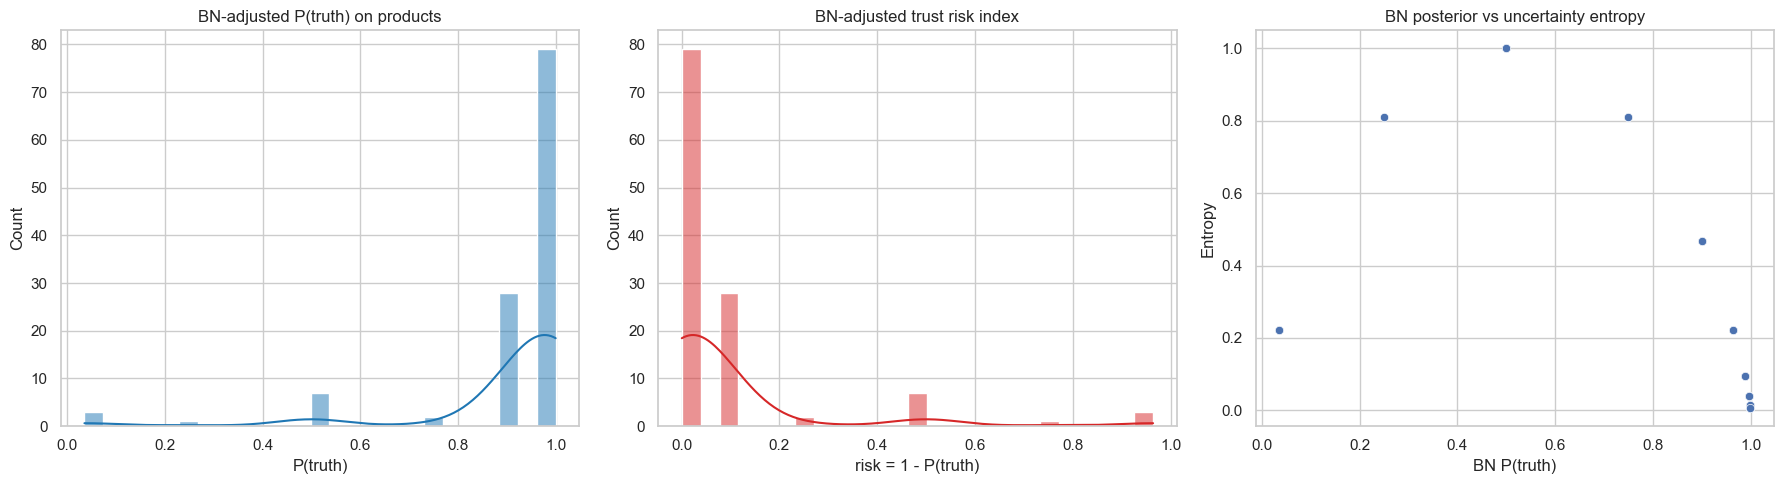

In [17]:
# 4) Phase B (Products): BN/logistic adjusted outcomes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(phase_b_scored['phase_b_truth_likelihood_graph'], bins=25, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('BN-adjusted P(truth) on products')
axes[0].set_xlabel('P(truth)')
sns.histplot(phase_b_scored['trust_risk_index_graph'], bins=25, kde=True, ax=axes[1], color='tab:red')
axes[1].set_title('BN-adjusted trust risk index')
axes[1].set_xlabel('risk = 1 - P(truth)')
sns.scatterplot(
    data=phase_b_scored,
    x='phase_b_truth_likelihood_graph',
    y='graph_uncertainty_entropy',
    ax=axes[2],
)
axes[2].set_title('BN posterior vs uncertainty entropy')
axes[2].set_xlabel('BN P(truth)')
axes[2].set_ylabel('Entropy')
plt.tight_layout()
plt.show()


### Visualization 5: BN Graph and Example Product Explanations

This cell first visualizes the BN dependency structure used for adjustment, then lists 3 representative products (low/median/high BN truth likelihood) with both raw LLM labels and BN-adjusted outcomes for interpretability.


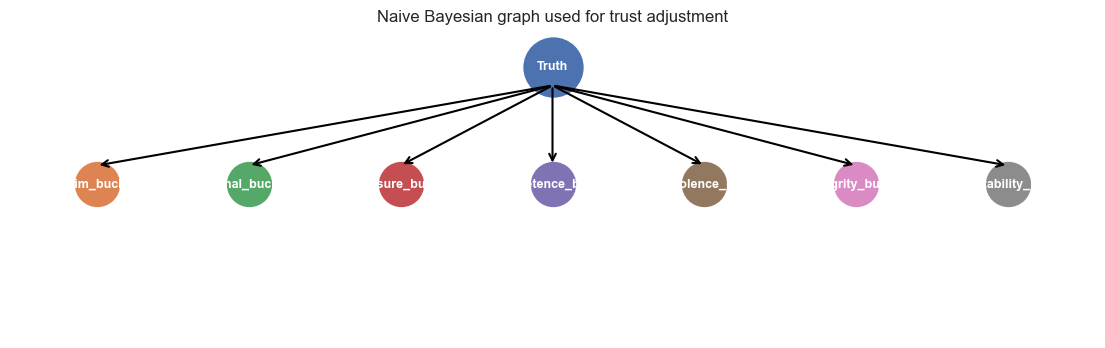

,record_id,TITLE,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,phase_b_truth_likelihood_graph,trust_risk_index_graph,graph_uncertainty_entropy
0,260809,"H Ristiyanl K Taslaklar: Ke I, Arnavutluk Katolik Kilisesi, Religious Society of Friends,",0.5,0.2,0.8,0.4,0.6,0.30,0.50,0.035714,0.964286,0.222285
60,667089,Fukuzawa Yukichi’s Bourgeois Liberalism: The Betrayal of the East Asian Enlightenment (Cri,0.5,1.0,0.0,0.8,0.9,0.95,0.85,0.995902,0.004098,0.038404
119,2131923,Jenny And Juju Table Runner -The Style of Our Table Linen and Dining Rooms and Eating Area,0.8,0.9,0.2,0.7,0.6,0.80,0.90,0.999543,0.000457,0.005730


In [18]:
# 5) BN structure + 3 sample product records (LLM labels and BN-adjusted outcomes)
# Simple BN structure visualization used in this notebook:
# Truth -> {claim_bucket, signal_bucket, pressure_bucket, competence_bucket, benevolence_bucket, integrity_bucket, predictability_bucket}
bn_nodes = [
    'Truth',
    'claim_bucket', 'signal_bucket', 'pressure_bucket',
    'competence_bucket', 'benevolence_bucket', 'integrity_bucket', 'predictability_bucket'
]
pos = {
    'Truth': (0.5, 0.88),
    'claim_bucket': (0.08, 0.50),
    'signal_bucket': (0.22, 0.50),
    'pressure_bucket': (0.36, 0.50),
    'competence_bucket': (0.50, 0.50),
    'benevolence_bucket': (0.64, 0.50),
    'integrity_bucket': (0.78, 0.50),
    'predictability_bucket': (0.92, 0.50),
}
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
for node in bn_nodes:
    x, y = pos[node]
    ax.scatter([x], [y], s=1800 if node == 'Truth' else 1000, zorder=3)
    ax.text(x, y, node, ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=4)
for child in bn_nodes[1:]:
    x1, y1 = pos['Truth']
    x2, y2 = pos[child]
    ax.annotate('', xy=(x2, y2 + 0.06), xytext=(x1, y1 - 0.06),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.set_title('Naive Bayesian graph used for trust adjustment')
plt.show()
# Pick 3 representative products: lowest, median, highest BN truth likelihood
ordered = phase_b_scored.sort_values('phase_b_truth_likelihood_graph').reset_index(drop=True)
if len(ordered) >= 3:
    idxs = [0, len(ordered) // 2, len(ordered) - 1]
else:
    idxs = list(range(len(ordered)))
sample_products = ordered.iloc[idxs].copy()
sample_cols = [
    'record_id',
    'TITLE',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'phase_b_truth_likelihood_graph', 'trust_risk_index_graph', 'graph_uncertainty_entropy'
]
sample_cols = [c for c in sample_cols if c in sample_products.columns]
if 'TITLE' in sample_products.columns:
    sample_products['TITLE'] = sample_products['TITLE'].astype(str).str.slice(0, 90)
display(sample_products[sample_cols])


### Visualization 6: High/Low News Samples Per Trust Factor

This cell selects one fake-news record with the highest score and one with the lowest score for each of the 7 factors (14 rows total target). It helps you audit what the label extremes look like in actual text.


In [19]:
# 6) Phase A: high/low sample news per factor (14 rows target)
factors = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
news_cols = ['record_id', 'label_truth', 'text'] + factors
news_cols = [c for c in news_cols if c in phase_a_labeled.columns]
phase_a_base = phase_a_labeled[news_cols].copy()
rows = []
for factor in factors:
    if factor not in phase_a_base.columns:
        continue
    high_idx = phase_a_base[factor].idxmax()
    low_idx = phase_a_base[factor].idxmin()
    high_row = phase_a_base.loc[high_idx].copy()
    high_row['factor'] = factor
    high_row['extreme'] = 'high'
    high_row['selected_score'] = float(high_row[factor])
    low_row = phase_a_base.loc[low_idx].copy()
    low_row['factor'] = factor
    low_row['extreme'] = 'low'
    low_row['selected_score'] = float(low_row[factor])
    rows.append(high_row)
    rows.append(low_row)
extremes_df = pd.DataFrame(rows).reset_index(drop=True)
if 'text' in extremes_df.columns:
    extremes_df['text_preview'] = extremes_df['text'].astype(str).str.slice(0, 180)
display_cols = [
    'factor', 'extreme', 'record_id', 'label_truth', 'selected_score',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'text_preview'
]
display_cols = [c for c in display_cols if c in extremes_df.columns]
print('Requested rows: 14 | Returned rows:', len(extremes_df))
print('Unique records among selected rows:', extremes_df['record_id'].nunique() if 'record_id' in extremes_df.columns else 'N/A')
display(extremes_df[display_cols])


Requested rows: 14 | Returned rows: 14
Unique records among selected rows: 4


,factor,extreme,record_id,label_truth,selected_score,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,text_preview
0,claim_trust_score,high,syn_2,1,0.9,0.9,1.0,0.0,0.8,0.7,0.9,0.6,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes."
1,claim_trust_score,low,syn_1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!
2,signal_trust_score,high,syn_2,1,1.0,0.9,1.0,0.0,0.8,0.7,0.9,0.6,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes."
3,signal_trust_score,low,syn_1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!
4,heuristic_pressure_score,high,syn_1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!
5,heuristic_pressure_score,low,syn_2,1,0.0,0.9,1.0,0.0,0.8,0.7,0.9,0.6,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes."
6,competence_score,high,syn_2,1,0.8,0.9,1.0,0.0,0.8,0.7,0.9,0.6,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes."
7,competence_score,low,syn_1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!
8,benevolence_score,high,syn_2,1,0.7,0.9,1.0,0.0,0.8,0.7,0.9,0.6,"City council approved a $12M transit upgrade after a 7-2 vote, according to meeting minutes."
9,benevolence_score,low,syn_1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5,Breaking: Scientists confirm Earth has two moons visible every night. Government hides this truth!
